# Loan Risk Classification
## Data Analytics project 25/26

**Models link** Models ['https://drive.google.com/file/d/1KJyh0enu0utSTqYFNocyjgCjIBUhFqFb/view?usp=sharing']

**Structure:**
- `config.py`: paths, seed, device
- `data_processing.py`: feature engineering, ML & DL preprocessors
- `models.py`: FFNN, TabNet, TabTransformer, training loop, evaluation
- `ml_pipeline.py`: RF, KNN, SVM grid search wrappers

## 0. Setup & Imports

In [ ]:
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from config import SEED, DEVICE, MODEL_DIR, TRAIN_CSV, fix_random
from data_processing import (
    load_data,
    prepare_ml_data,
    prepare_dl_data,
    FFNNPreprocessor,
)
from ml_pipeline import (
    train_random_forest,
    train_knn,
    train_svm,
    train_lr,
    save_split_model,
    print_grid_results,
    plot_rf_feature_importances,
)
from models import (
    LoanDataset,
    TabularDataset,
    LoanClassifierFFNN,
    build_tabnet_classifier,
    train_tabnet,
    build_tab_transformer,
    train_model,
    evaluate_model,
    plot_losses,
    plot_confusion_matrix,
    plot_feature_importances,
    get_class_weights,
    get_class_weights_dict,
    create_loaders,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score, 
    f1_score, 
    classification_report,
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import (
    RobustScaler, 
    StandardScaler, 
    MinMaxScaler
)

fix_random(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Data Loading & Visualization

In [2]:
df = load_data(TRAIN_CSV)
df.head()

Loaded 148301 rows  (dropped 0 duplicates)


,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_term_months,loan_contract_interest_rate,loan_payment_installments_count,borrower_profile_employment_length,borrower_housing_ownership_status,borrower_income_annual,borrower_income_verification_status,...,hardship_last_payment_amount_total,disbursement_method_type,debt_settlement_flag_indicator,debt_settlement_flag_date,settlement_status_label,settlement_date,settlement_amount_total,settlement_percentage,settlement_term_months,grade
0,12000.0,11819.212488,12000.000000,36 months,12.806304,395.66,10+ years,rent,40000.0,source verified,...,NaN,cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
1,10000.0,10683.410001,10023.226279,36 months,7.890000,312.86,2 years,rent,NaN,not verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,A
2,7000.0,7000.000000,5989.447426,36 months,18.558177,253.04,8 years,mortgage,120000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,D
3,35000.0,35000.000000,35000.000000,60 months,22.950000,985.67,NaN,mortgage,99588.0,verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,F
4,2400.0,2437.596602,2400.000000,36 months,13.990000,82.02,2 years,rent,37000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148301 entries, 0 to 148300
Columns: 145 entries, loan_contract_approved_amount to grade
dtypes: float64(112), object(33)
memory usage: 164.1+ MB


/var/folders/c4/m_6w9kxs5kj6jyfn6b9_dsbr0000gn/T/ipykernel_25470/3926484378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


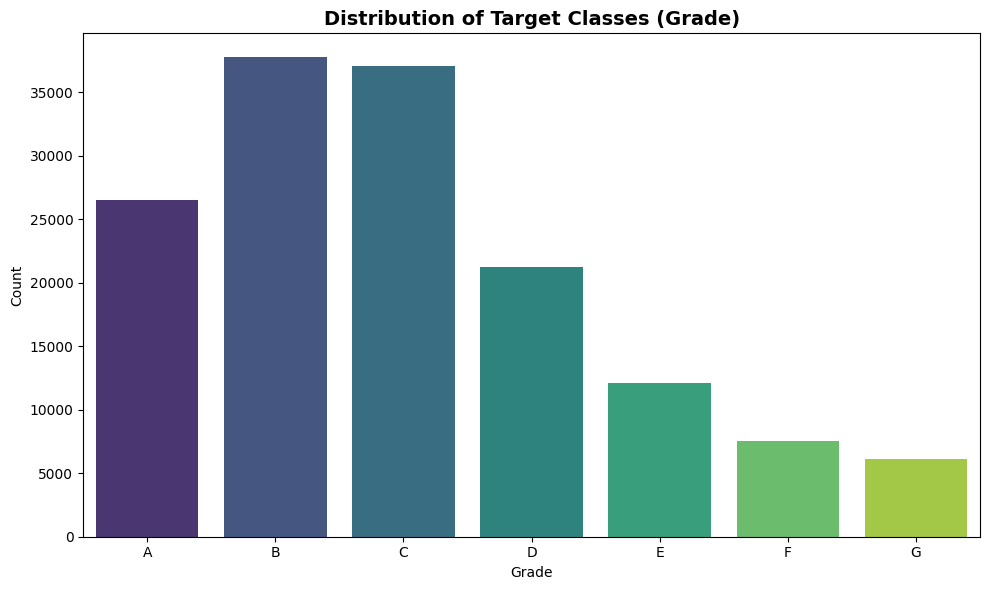

In [4]:
# Target distribution
class_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Target Classes (Grade)", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

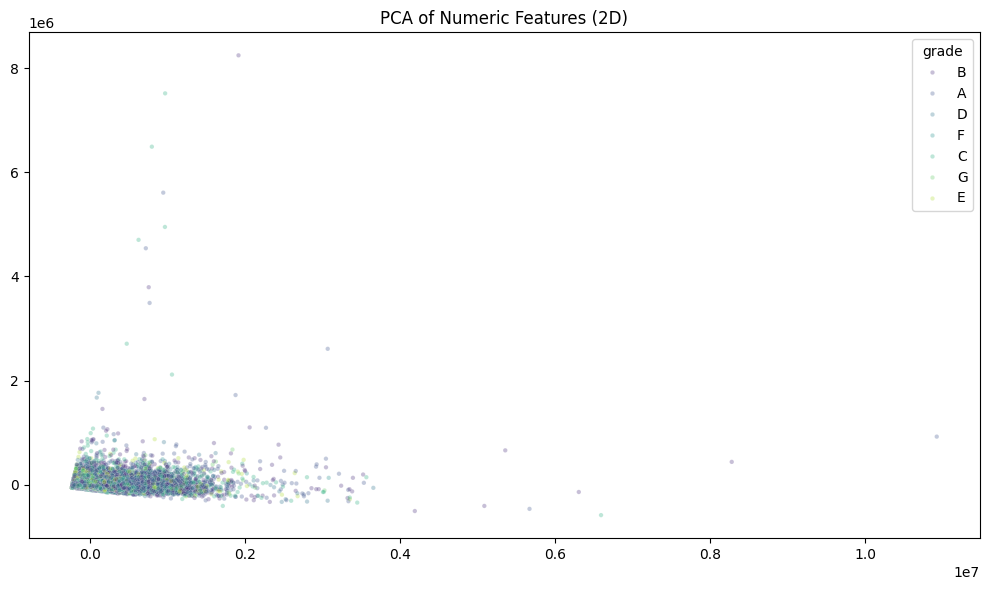

In [5]:
# PCA visualization
X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
X_pca = PCA(n_components=2).fit_transform(X_numeric)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grade"], palette="viridis", alpha=0.3, s=10)
plt.title("PCA of Numeric Features (2D)")
plt.tight_layout()
plt.show()

## 2. ML Models

The ML pipeline uses all the data with `GridSearchCV` (3-fold stratified CV).

In [6]:
X_raw, y_raw, fe_instance, prep_instance, le = prepare_ml_data(TRAIN_CSV)
print("X_raw shape:", X_raw.shape)
X_raw.head()

Data Loaded: (148301, 144). Returned raw X, y and unfitted preprocessors.
X_raw shape: (148301, 144)


,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_term_months,loan_contract_interest_rate,loan_payment_installments_count,borrower_profile_employment_length,borrower_housing_ownership_status,borrower_income_annual,borrower_income_verification_status,...,hardship_payoff_balance,hardship_last_payment_amount_total,disbursement_method_type,debt_settlement_flag_indicator,debt_settlement_flag_date,settlement_status_label,settlement_date,settlement_amount_total,settlement_percentage,settlement_term_months
0,12000.0,11819.212488,12000.000000,36 months,12.806304,395.66,10+ years,rent,40000.0,source verified,...,NaN,NaN,cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000.0,10683.410001,10023.226279,36 months,7.890000,312.86,2 years,rent,NaN,not verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN
2,7000.0,7000.000000,5989.447426,36 months,18.558177,253.04,8 years,mortgage,120000.0,source verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN
3,35000.0,35000.000000,35000.000000,60 months,22.950000,985.67,NaN,mortgage,99588.0,verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN
4,2400.0,2437.596602,2400.000000,36 months,13.990000,82.02,2 years,rent,37000.0,source verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
X_raw["secondary_applicant_earliest_credit_line"]

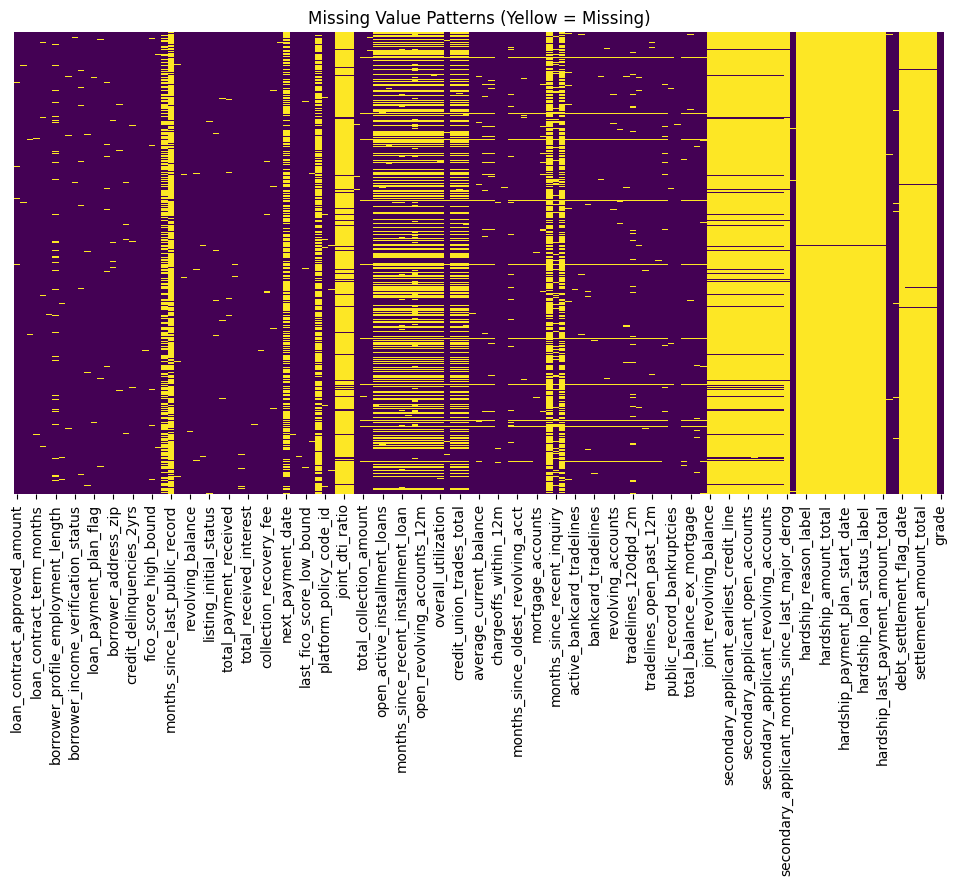

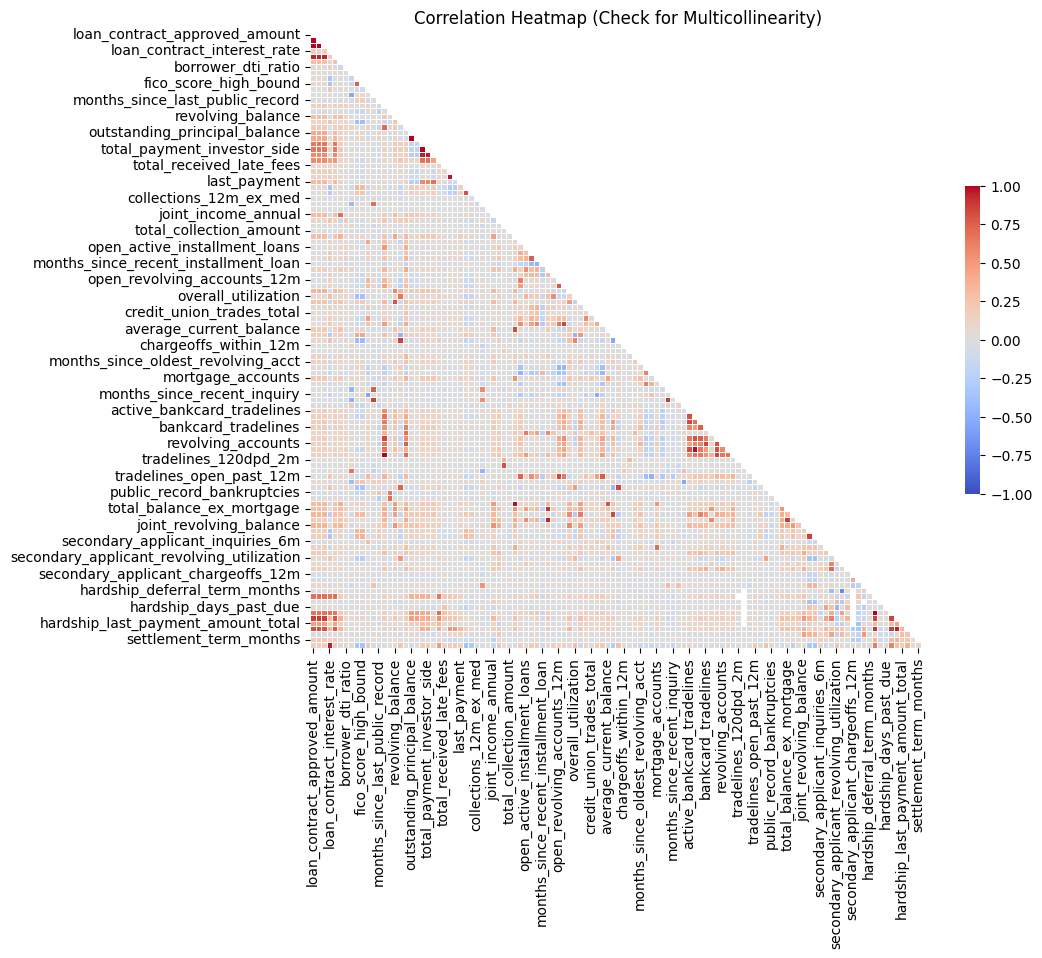

In [ ]:
def visualize_data_quality(X, y):
    """
    Generates 4 key plots for Loan Risk Analysis.
    """
    # Combine for easier plotting
    df_plot = X.copy()
    df_plot['grade'] = y
    
    plt.figure(figsize=(12, 6))
    # Plot missing values as binary (White=Missing, Black=Present)
    sns.heatmap(df_plot.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Value Patterns (Yellow = Missing)")
    plt.show()

    # correlation heatmap (to check multicollinearity)
    num_df = df_plot.select_dtypes(include=[np.number])
    corr = num_df.corr()
    
    plt.figure(figsize=(10, 8))
    # Mask the upper triangle (redundant)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Correlation Heatmap (Check for Multicollinearity)")
    plt.show()

    key_features = [
        'loan_contract_interest_rate', 
        'loan_contract_approved_amount',  
        'loan_portfolio_total_funded'    
    ]
    
    # Check if they exist in dataset (some might be named differently)
    valid_feats = [f for f in key_features if f in df_plot.columns]
    
    if valid_feats:
        plt.figure(figsize=(15, 5))
        for i, col in enumerate(valid_feats):
            plt.subplot(1, 3, i+1)
            # Order grades A->G
            order = sorted(df_plot['grade'].unique())
            sns.boxplot(x='grade', y=col, data=df_plot, order=order, showfliers=False) # Hide outliers for clarity
            plt.title(f"{col} by Grade")
        plt.tight_layout()
        plt.show()

    # Distribution of a skewed numeric feature before/after log transform
    col = 'loan_contract_approved_amount'
    if col in df_plot.columns:
        plt.figure(figsize=(12, 5))
        
        # Original
        plt.subplot(1, 2, 1)
        sns.histplot(df_plot[col], kde=True, bins=50)
        plt.title(f"Original {col} (Skewed)")
        plt.xlabel("Value")
        
        # Log Transformed
        plt.subplot(1, 2, 2)
        log_val = np.log1p(df_plot[col])
        sns.histplot(log_val, kde=True, bins=50, color='green')
        plt.title(f"Log-Transformed {col} (Normal-ish)")
        plt.xlabel("Log(Value)")
        
        plt.tight_layout()
        plt.show()

# --- RUN IT ---
# Assuming X_raw and y_raw are defined from your previous steps
visualize_data_quality(X_raw, y_raw)

In [ ]:
def visualize_interactions(X, y):
    """
    Generates 2 key plots for Loan Risk Analysis.
    """
    df_plot = X.copy()
    df_plot['grade'] = y
    
    # Sort grades for clean plotting
    grade_order = sorted(df_plot['grade'].unique())
    
    # risk pricing scatter (FICO vs Interest Rate)
    fico_col = 'last_fico_score_low_bound' if 'last_fico_score_low_bound' in df_plot else None
    
    # Fallback if specific fico col isn't found
    if not fico_col:
        # Try finding any column with 'fico' in it
        ficos = [c for c in df_plot.columns if 'fico' in c]
        if ficos: fico_col = ficos[0]

    if fico_col and 'int_rate' in df_plot.columns:
        plt.figure(figsize=(10, 6))
        
        # Downsample for speed/clarity if > 10k rows
        if len(df_plot) > 10000:
            plot_data = df_plot.sample(5000, random_state=42)
        else:
            plot_data = df_plot
            
        sns.scatterplot(
            data=plot_data, 
            x=fico_col, 
            y='int_rate', 
            hue='grade', 
            hue_order=grade_order,
            palette='viridis', 
            alpha=0.6,
            edgecolor=None
        )
        plt.title(f"Risk Pricing: {fico_col} vs Interest Rate (Colored by Grade)")
        plt.grid(True, alpha=0.3)
        plt.show()

    # Categorical feature interaction (e.g., Home Ownership vs Grade)
    if 'borrower_housing_ownership_status' in df_plot.columns:
        col_name = 'borrower_housing_ownership_status'
    elif 'home_ownership' in df_plot.columns:
        col_name = 'home_ownership'
    else:
        col_name = None

    if col_name:
        plt.figure(figsize=(10, 5))
        
        # Calculate counts per grade/status
        props = df_plot.groupby(['grade', col_name]).size().reset_index(name='counts')
        
        # Convert to percentages within each Grade to compare "composition"
        # (i.e., What % of Grade A owns homes vs What % of Grade G owns homes)
        totals = props.groupby('grade')['counts'].transform('sum')
        props['percent'] = props['counts'] / totals
        
        sns.histplot(
            data=df_plot.sort_values('grade'),
            x='grade',
            hue=col_name,
            multiple='fill', # This creates a 100% stacked bar
            shrink=0.8
        )
        plt.title(f"Composition of Grades by {col_name} (Normalized)")
        plt.ylabel("Proportion")
        plt.show()

# Run
visualize_interactions(X_raw, y_raw)

In [ ]:
def visualize_outliers(X, y):
    """
    Generates 2 key plots for Outlier Detection in Loan Risk Analysis.
    """
    df_plot = X.copy()
    df_plot['grade'] = y
    
    # We check for standard column names
    inc_col = 'annual_inc'
    loan_col = 'loan_contract_approved_amount'
    
    if inc_col in df_plot.columns and loan_col in df_plot.columns:
        plt.figure(figsize=(10, 6))
        
        # Use log scale for axes to handle the massive skew in financial data
        plt.xscale('log')
        plt.yscale('log')
        
        sns.scatterplot(
            data=df_plot,
            x=inc_col,
            y=loan_col,
            hue='grade',
            hue_order=sorted(df_plot['grade'].unique()),
            palette='coolwarm_r', # Red = A (Safe), Blue = G (Risky) roughly
            alpha=0.5,
            s=15
        )
        
        # Add a reference line for 1:1 ratio (just as a visual guide)
        # (Optional, but helps see leverage)
        
        plt.title("Leverage Outliers: Income vs Loan Amount (Log-Log Scale)")
        plt.xlabel("Annual Income (Log)")
        plt.ylabel("Loan Amount (Log)")
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.show()
        print("Insight: Look for points in the Top-Left corner (High Loan / Low Income).")

    # ------------------------------------------------------
    # 8. STRESS DISTRIBUTION (Violin Plot of DTI)
    # ------------------------------------------------------
    # DTI is often named 'dti' or 'borrower_dti_ratio'
    dti_col = 'dti' if 'dti' in df_plot.columns else 'borrower_dti_ratio'
    
    if dti_col in df_plot.columns:
        plt.figure(figsize=(12, 6))
        
        # Clip huge outliers just for plotting readability (e.g. DTI > 100 is likely bad data)
        plot_data = df_plot[df_plot[dti_col] <= 60] 
        
        sns.violinplot(
            data=plot_data,
            x='grade',
            y=dti_col,
            order=sorted(df_plot['grade'].unique()),
            palette='muted',
            inner='quartile' # Draws lines for median/quartiles inside
        )
        
        plt.title(f"Distribution of DTI (Debt-to-Income) by Grade (Capped at 60)")
        plt.ylabel("DTI Ratio")
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        print("Insight: The 'thicker' the top part of the violin, the more high-debt borrowers in that grade.")

# Run
visualize_outliers(X_raw, y_raw)

## 2.1 Logistic Regression

In [ ]:
# lr_param_grid = {
#     "preprocessor__scaler": [StandardScaler(), RobustScaler()], 
#     "classifier__C": [0.1, 1, 10], 
#     "classifier__solver": ["lbfgs"],
#     "classifier__penalty": ["l2", "l1"],
#     "classifier__max_iter": [1000]
# }

lr_param_grid = {
    "preprocessor__scaler": [RobustScaler()], 
    "classifier__C": [10], 
    "classifier__solver": ["lbfgs"],
    "classifier__penalty": ["l2"],
    "classifier__max_iter": [1000]
}

gs_lr = train_lr(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=lr_param_grid,
    cv=3
)

Starting Logistic Regression GridSearch...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


In [ ]:
# try:
#     save_split_model(gs_lr, "lr")
# except Exception as e:
#     print(f"Error saving model: {e}")

print_grid_results(gs_lr, "Logistic Regression")

[LR] Saved Successfully:
  Preprocessor: models/lr_preprocessor.pkl
  Classifier:   models/lr_classifier.pkl

  Logistic Regression — Best GridSearch Results
  Best Params: {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs', 'preprocessor__scaler': RobustScaler()}

  accuracy                 : 0.8514 ± 0.0026
  balanced_accuracy        : 0.8080 ± 0.0038
  f1_weighted              : 0.8517 ± 0.0025
  f1_macro                 : 0.8001 ± 0.0038



### 2.1 Random Forest

In [ ]:
rf_param_grid = {
    "classifier__n_estimators": [300],
    "classifier__max_depth": [None],
    "classifier__min_samples_split": [8],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": [0.3],
}

gs_rf = train_random_forest(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=rf_param_grid,
    cv=3
)

In [ ]:
try:
    save_split_model(gs_rf, "rf")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_rf, "Random Forest")

In [ ]:
plot_rf_feature_importances(gs_rf, top_k=20, save_path=os.path.join(MODEL_DIR + "/images", "rf_fi.png"))

### 2.2 KNN

In [ ]:
knn_param_grid = {
    "pca__n_components": [30],
    "preprocessor__scaler": [StandardScaler()],
    "classifier__n_neighbors": [30],
    "classifier__weights": ["distance"],
    "classifier__p": [2],
}

gs_knn = train_knn(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=knn_param_grid,
    cv=3
)

In [ ]:
try:
    save_split_model(gs_knn, "knn")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_knn, "KNN")

### 2.3 SVM

In [ ]:
svm_param_grid = {
    "preprocessor__scaler": [StandardScaler()],
    "classifier__C": [100],
    "classifier__kernel": ["rbf"],
    "classifier__gamma": ["scale"],
    "classifier__max_iter": [1000],
}

gs_svm = train_svm(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=svm_param_grid,
    cv=3
)

In [ ]:
try:
    save_split_model(gs_svm, "svm")
except Exception as e:
    print(f"Error saving model: {e}")
    
print_grid_results(gs_svm, "SVM")

## 3. Deep Learning Models

DL uses an explicit train/val/test split. Preprocessing is fit on train only.

In [ ]:
# Prepare DL data
dl_data_raw = prepare_dl_data(TRAIN_CSV, val_size=0.10, test_size=0.10)

In [ ]:
print(f"\nDL data shapes:")
print(f"  X_train: {dl_data_raw['X_train'].shape}")
print(f"  X_val  : {dl_data_raw['X_val'].shape}")
print(f"  X_test : {dl_data_raw['X_test'].shape}")
print(f"  Num cols: {dl_data_raw['num_num_cols']}, Cat cols: {dl_data_raw['num_cat_cols']}")
print(f"  Classes : {dl_data_raw['num_classes']}")
print(f"  Feature names ({len(dl_data_raw['feature_names'])}): {dl_data_raw['feature_names'][:10]}...")

In [ ]:
# Instantiate the class
dl_pipeline = FFNNPreprocessor()

print("Fitting DL Preprocessor...")
dl_pipeline.fit(dl_data_raw['X_train'])

# Save preprocessor for ffnn, tabNet and tabTransformer
with open("models/ffnn_preprocessor.pkl", "wb") as f:
    pickle.dump(dl_pipeline, f)
print("Saved models/ffnn_preprocessor.pkl")

In [ ]:
X_train_np = dl_pipeline.transform(dl_data_raw['X_train'])
X_val_np   = dl_pipeline.transform(dl_data_raw['X_val'])
X_test_np  = dl_pipeline.transform(dl_data_raw['X_test'])

print(f"\nDL data shapes:")
print(f"  X_train: {X_train_np.shape}")
print(f"  X_val  : {X_val_np.shape}")
print(f"  X_test : {X_test_np.shape}")

meta = dl_pipeline.get_metadata()
print(f"Metadata Extracted: {meta['num_num_cols']} numeric, {meta['num_cat_cols']} categorical")

In [ ]:
# Class weights (shared across all DL models)
class_weights_array = get_class_weights(dl_data_raw["y_train"])
class_weights_dict = get_class_weights_dict(dl_data_raw["y_train"])
class_names = [f"Grade {c}" for c in dl_data_raw["label_encoder"].classes_]
feature_names = dl_data_raw["feature_names"]

print(f"Class weights: {dict(enumerate(class_weights_array))}")
print(f"Class names: {class_names}")
print(f"Feature names: {len(feature_names)} total")

for name, y in [("Train", dl_data_raw["y_train"]),
                ("Val",   dl_data_raw["y_val"]),
                ("Test",  dl_data_raw["y_test"])]:
    unique, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    print(f"{name:5s}: {dict(zip(unique, [f'{p:.1f}%' for p in pcts]))}")

### 3.1 TabNet

In [ ]:
# ── TabNet Hyperparameters (edit here) ──
TABNET_HP = dict(
    # Architecture
    n_d=64,
    n_a=64,
    n_steps=3,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    cat_emb_dim=10,
    # Optimization
    lr=0.02,
    scheduler_step_size=20,
    scheduler_gamma=0.7,
    # Regularization
    lambda_sparse=1e-5,
    momentum=0.02,
    mask_type="entmax",
    # Training
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)

In [ ]:
# Build TabNet
tabnet_model = build_tabnet_classifier(
    cat_indices=meta["cat_indices"],
    cat_cardinalities=meta["cat_cardinalities"],
    device=DEVICE,
    seed=SEED,
    n_d=TABNET_HP["n_d"],
    n_a=TABNET_HP["n_a"],
    n_steps=TABNET_HP["n_steps"],
    gamma=TABNET_HP["gamma"],
    n_independent=TABNET_HP["n_independent"],
    n_shared=TABNET_HP["n_shared"],
    cat_emb_dim=TABNET_HP["cat_emb_dim"],
    lr=TABNET_HP["lr"],
    scheduler_step_size=TABNET_HP["scheduler_step_size"],
    scheduler_gamma=TABNET_HP["scheduler_gamma"],
    lambda_sparse=TABNET_HP["lambda_sparse"],
    momentum=TABNET_HP["momentum"],
    mask_type=TABNET_HP["mask_type"],
)

In [ ]:
# Train TabNet
tabnet_model = train_tabnet(
    model=tabnet_model,
    X_train=X_train_np,
    y_train=dl_data_raw["y_train"],
    X_val=X_val_np,
    y_val=dl_data_raw["y_val"],
    max_epochs=TABNET_HP["max_epochs"],
    patience=TABNET_HP["patience"],
    batch_size=TABNET_HP["batch_size"],
    virtual_batch_size=TABNET_HP["virtual_batch_size"],
    class_weights=class_weights_dict,
)

In [ ]:
# Plot TabNet training history
tabnet_train_loss = tabnet_model.history["loss"]
tabnet_val_loss = tabnet_model.history["val_0_logloss"]
plot_losses(tabnet_train_loss, tabnet_val_loss, title="TabNet: Training vs Validation Loss")

In [ ]:

y_pred_tabnet = tabnet_model.predict(X_test_np)
y_test = dl_data_raw["y_test"]

print(f"\n{'='*50}")
print(f"  TabNet Test Set Evaluation")
print(f"{'='*50}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  F1 (weighted)     : {f1_score(y_test, y_pred_tabnet, average='weighted'):.4f}")
print(f"  F1 (macro)        : {f1_score(y_test, y_pred_tabnet, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tabnet, target_names=class_names))

plot_confusion_matrix(y_test, y_pred_tabnet, class_names=class_names, title="TabNet Confusion Matrix")

In [ ]:
# 1. Extract the feature names from the internal ColumnTransformer
# The ColumnTransformer stores the columns used for each step in .transformers_
# structure: [(name, transformer, columns), ...]

ct = dl_pipeline.dl_preprocessor_

# Index 0 is the "num" pipeline (Numerical)
# Index 1 is the "cat" pipeline (Categorical)
num_cols = ct.transformers_[0][2]
cat_cols = ct.transformers_[1][2]

# The output array is always [Numerical features | Categorical features]
correct_feature_names = num_cols + cat_cols

print(f"Correct feature count: {len(correct_feature_names)}") 
# 2. Now plot with the correct names
plot_feature_importances(
    importances=tabnet_model.feature_importances_,
    feature_names=correct_feature_names,
    top_k=20,
    title="TabNet — Feature Importances",
)

In [ ]:
#tabnet_save_path = os.path.join(MODEL_DIR, "best_tabnet")
#tabnet_model.save_model(tabnet_save_path)
#print(f"TabNet model saved to {tabnet_save_path}")

with open("models/tb.pkl", "wb") as f:
    pickle.dump(tabnet_model, f)

### 3.2 Feed-Forward Neural Network (FFNN)

In [ ]:
FFNN_HP = dict(
    # Architecture
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.05],
    # Training
    num_epochs=300,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=25,
    scheduler_patience=5,
    scheduler_factor=0.3,
)

In [ ]:
train_ds = LoanDataset(X_train_np, dl_data_raw["y_train"])
val_ds   = LoanDataset(X_val_np,   dl_data_raw["y_val"])
test_ds  = LoanDataset(X_test_np,  dl_data_raw["y_test"])

train_loader, val_loader, test_loader = create_loaders(
    train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
)

print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

In [ ]:
fix_random(SEED)

ffnn_model = LoanClassifierFFNN(
    input_dim=train_ds.num_features,
    output_dim=train_ds.num_classes,
    hidden_units=FFNN_HP["hidden_units"],
    dropout_rates=FFNN_HP["dropout_rates"],
).to(DEVICE)

print(ffnn_model)
print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")

In [ ]:
ffnn_model, t_losses, v_losses = train_model(
    model=ffnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=FFNN_HP["num_epochs"],
    patience=FFNN_HP["patience"],
    learning_rate=FFNN_HP["learning_rate"],
    weight_decay=FFNN_HP["weight_decay"],
    scheduler_patience=FFNN_HP["scheduler_patience"],
    scheduler_factor=FFNN_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="ff.pkl",
    model_type="standard",
)

plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")

In [ ]:
ffnn_results = evaluate_model(
    ffnn_model, test_loader, DEVICE,
    class_names=class_names, model_type="standard", set_name="FFNN Test"
)
plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
                      class_names=class_names, title="FFNN Confusion Matrix")



### 3.3 Tab Transformer

In [ ]:
# ── TabTransformer Hyperparameters (edit here) ──
TABT_HP = dict(
    # Architecture
    dim=8,
    depth=2,
    heads=4,
    attn_dropout=0.5,
    ff_dropout=0.5,
    mlp_hidden_mults=(2, 1),
    # Training
    num_epochs=100,
    batch_size=2048,
    learning_rate=3e-4,
    weight_decay=0.05,
    patience=10,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=10,
)

In [ ]:
# Build datasets (TabularDataset splits num/cat)
n_num = dl_data_raw["num_num_cols"]

train_ds_tt = TabularDataset(X_train_np, dl_data_raw["y_train"], meta["num_num_cols"])
val_ds_tt   = TabularDataset(X_val_np,   dl_data_raw["y_val"],   meta["num_num_cols"])
test_ds_tt  = TabularDataset(X_test_np,  dl_data_raw["y_test"],  meta["num_num_cols"])

train_loader_tt, val_loader_tt, test_loader_tt = create_loaders(
    train_ds_tt, val_ds_tt, test_ds_tt, batch_size=TABT_HP["batch_size"]
)

print(f"Numeric: {train_ds_tt.n_num}, Categorical: {train_ds_tt.n_cat}")

In [ ]:
# Build & train TabTransformer
fix_random(SEED)

tab_transformer = build_tab_transformer(
    cat_cardinalities=tuple(meta["cat_cardinalities"]),
    num_continuous=meta["num_num_cols"],
    cont_mean_std=meta["cont_mean_std"],
    num_classes=dl_data_raw["num_classes"],
    dim=TABT_HP["dim"],
    depth=TABT_HP["depth"],
    heads=TABT_HP["heads"],
    attn_dropout=TABT_HP["attn_dropout"],
    ff_dropout=TABT_HP["ff_dropout"],
    mlp_hidden_mults=TABT_HP["mlp_hidden_mults"],
    device=DEVICE,
)

print(tab_transformer)
print(f"Parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

In [ ]:
tab_transformer, t_losses_tt, v_losses_tt = train_model(
    model=tab_transformer,
    train_loader=train_loader_tt,
    val_loader=val_loader_tt,
    num_epochs=TABT_HP["num_epochs"],
    patience=TABT_HP["patience"],
    learning_rate=TABT_HP["learning_rate"],
    weight_decay=TABT_HP["weight_decay"],
    #scheduler_patience=TABT_HP["scheduler_patience"],
    #scheduler_factor=TABT_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="tf.pkl",
    model_type="tab_transformer",
    max_grad_norm=TABT_HP.get("max_grad_norm"),
    use_cosine_scheduler=TABT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=TABT_HP.get("warmup_epochs", 0)
)

plot_losses(t_losses_tt, v_losses_tt, title="TabTransformer: Training vs Validation Loss")

In [ ]:
# Evaluate TabTransformer
tt_results = evaluate_model(
    tab_transformer, test_loader_tt, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="TabTransformer Test"
)
plot_confusion_matrix(tt_results["y_true"], tt_results["y_pred"],
                      class_names=class_names, title="TabTransformer Confusion Matrix")

In [ ]:
# 1. Import the wrapper FROM the file (so pickle knows where it lives)
from data_processing import TabTransformerInferenceWrapper
import pickle

# 2. Load your best trained weights
# (Assuming train_model saved "best_tab_transformer.pkl")
with open("models/best_tab_transformer.pkl", "rb") as f:
    best_tt_model = pickle.load(f)

# 3. Get the number of numeric columns
# (You have this in dl_data or meta)
n_num = meta["num_num_cols"] 

# 4. Wrap the model
inference_model = TabTransformerInferenceWrapper(best_tt_model, n_num)
inference_model.eval()
inference_model.cpu() # Essential for portability

# 5. Save the WRAPPER as the final classifier
with open("models/tabtransformer_classifier.pkl", "wb") as f:
    pickle.dump(inference_model, f)

print("Saved Wrapper Model to models/tabtransformer_classifier.pkl")

# 4. Overall Comparison

In [ ]:
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Bal Acc':>10} {'F1 macro':>10}")
print(f"{'-'*60}")

# ML models
for name, gs in [("Random Forest", gs_rf), ("KNN", gs_knn), ("SVM", gs_svm)]:
    idx = gs.best_index_
    acc = gs.cv_results_["mean_test_accuracy"][idx]
    bal = gs.cv_results_["mean_test_balanced_accuracy"][idx]
    f1m = gs.cv_results_["mean_test_f1_macro"][idx]
    print(f"{name:<20} {acc:>10.4f} {bal:>10.4f} {f1m:>10.4f}  (CV)")

# DL models 
print(f"{'FFNN':<20} {ffnn_results['accuracy']:>10.4f} {ffnn_results['balanced_accuracy']:>10.4f} {ffnn_results['f1_macro']:>10.4f}  (test)")

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_bal = balanced_accuracy_score(y_test, y_pred_tabnet)
tabnet_f1m = f1_score(y_test, y_pred_tabnet, average="macro")
print(f"{'TabNet':<20} {tabnet_acc:>10.4f} {tabnet_bal:>10.4f} {tabnet_f1m:>10.4f}  (test)")

print(f"{'TabTransformer':<20} {tt_results['accuracy']:>10.4f} {tt_results['balanced_accuracy']:>10.4f} {tt_results['f1_macro']:>10.4f}  (test)")